#### This script merges all stations included in the seven datasets:

In [19]:
import pandas as pd
from glob import glob
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import shapely
import os
import geodatasets

In [11]:
# define the output folder path:

output_folder = '../../output_data/merged_datasets'

# Check if the folder exists, if not, create it:
if not os.path.exists(output_folder):
    os.makedirs(output_folder)


In [12]:
#--- List files ---
inputFolder = '../../input_data/raw_station/'
files = glob(f'{inputFolder}*csv')
print([file.split('_')[-1].split('.')[0] for file in files])

['arcticdeltas', 'denmark', 'france', 'germany', 'GRQA', 'sweden', 'MU']


In [13]:
# --- Merge station data ---
list_out = []
for file in files:
    dataset_name = file.split('_')[-1].split('.')[0]
    delimiter = ','
    decimal = '.'
   # if dataset_name in['sweden','denmark']:
    if dataset_name == 'denmark' or dataset_name == 'sweden':
        delimiter = ';'
    if dataset_name=='denmark':
        decimal = ','
    #if dataset_name == 'sweden':
        #delimiter = '\t'
    station_data = pd.read_csv(file, delimiter=delimiter, decimal=decimal)

    #--- Column name consistency ---
    if dataset_name=='MU':
        station_data['country'] = 'USA'
        dataset_name = 'USGS'
    to_replace = {'Site':'site_id','Drainage.area..km2.':'area','Latitude':'lat','Longitude':'lon',
                  'Source':'data_source','longitude':'lon','latitude':'lat'}
    station_data = station_data.rename(columns=to_replace)
    cols = ['site_id', 'data_source', 'country', 'area', 'lat', 'lon']
    if dataset_name=='sweden':
        station_data['area'] = -9999
    if dataset_name in ['france']:
        station_data = station_data.rename(columns={'lat':'lon','lon':'lat'})
    station_data = station_data.replace(np.nan,-9999)
    
    #--- Print some information ---
    print('\n',dataset_name,'\n','columns:',station_data.columns.tolist())
    #print(station_data[cols].head(1).T)  
    print(station_data[cols].describe())
    print(len(station_data[cols]),len(station_data[cols].dropna()))
    
    #--- Append datasets ---
    station_data['dataset'] = dataset_name
    list_out.append(station_data[cols+['dataset']].copy())

merged_station_data = pd.concat(list_out,axis=0)


 arcticdeltas 
 columns: ['X', 'site_id', 'data_source', 'country', 'area', 'lat', 'lon']
               area        lat         lon
count  6.000000e+00   6.000000    6.000000
mean   1.855000e+06  66.818333   23.466667
std    9.399734e+05   2.631581  137.264274
min    6.500000e+05  61.930000 -162.880000
25%    1.072500e+06  66.665000  -83.655000
50%    2.100000e+06  67.110000   76.375000
75%    2.475000e+06  68.425000  114.065000
max    2.950000e+06  69.380000  161.300000
6 6

 denmark 
 columns: ['Unnamed: 0', 'site_id', 'data_source', 'country', 'area', 'lat', 'lon']
            site_id    area          lat          lon
count  3.760000e+03  3760.0  3760.000000  3760.000000
mean   3.040131e+07 -9999.0    55.964097     9.933523
std    1.351989e+07     0.0     0.575647     1.070175
min    1.000039e+06 -9999.0    54.732453     8.108544
25%    2.100068e+07 -9999.0    55.522094     9.234465
50%    2.600009e+07 -9999.0    56.001166     9.815029
75%    4.400018e+07 -9999.0    56.363985    1

In [14]:
merged_station_data

,site_id,data_source,country,area,lat,lon,dataset
0,Ob,ArcticGRO,Russia,2950000.000,66.630000,66.600000,arcticdeltas
1,Yenisey,ArcticGRO,Russia,2500000.000,69.380000,86.150000,arcticdeltas
2,Lena,ArcticGRO,Russia,2400000.000,66.770000,123.370000,arcticdeltas
3,Kolyma,ArcticGRO,Russia,1800000.000,68.750000,161.300000,arcticdeltas
4,Yukon,ArcticGRO,USA,830000.000,61.930000,-162.880000,arcticdeltas
...,...,...,...,...,...,...,...
1555,va9-NEW127.49,VA DEQ,USA,3496.880,36.835560,-80.951940,USGS
1556,va9-NEW148.23,VA DEQ,USA,2955.680,36.646390,-80.977780,USGS
1557,va9-RDC009.00,VA DEQ,USA,667.611,36.939060,-80.886920,USGS
1558,wa34A070,WA SDE,USA,6471.580,46.759038,-118.148016,USGS


In [15]:
#--- Post processing after merging ----
#-- Delete some empty fields --
merged_station_data = merged_station_data[merged_station_data.site_id!=-9999]
#-- Transform to geopandas (shapefile) --merged_station_data.groupby('dataset').count()['site_id']
geometry = [Point(xy) for xy in zip(merged_station_data.lon, merged_station_data.lat)]
gdf = gpd.GeoDataFrame(merged_station_data, crs="EPSG:4326", geometry=geometry)
#-- Sweden, some coordinates to swap--
gdf = gdf.set_index(['dataset','site_id'])
wrong_ind = [('sweden',i) for i in range(61,66)]
gdf_subset = gdf.loc[wrong_ind].copy()
gdf_subset['geometry'] = gdf_subset.geometry.map(lambda polygon: shapely.ops.transform(lambda x, y: (y, x), polygon))
gdf_subset['lat'] = gdf_subset.geometry.y.values
gdf_subset['lon'] = gdf_subset.geometry.x.values
gdf.loc[wrong_ind] = gdf_subset.loc[wrong_ind]
#-- Remove duplicated stations USGS dataset ---
print(gdf[gdf.index.duplicated()])
gdf = gdf[~gdf.index.duplicated(keep='first')]
print(gdf[gdf.index.duplicated()])
print(gdf.describe())
gdf = gdf.reset_index()
#gdf.to_file('stations.shp')
gdf.to_file('../../output_data/merged_datasets/stations.shp')

                         data_source  country          area        lat  \
dataset site_id                                                          
GRQA    201190               GLORICH   Brazil  1.714580e+10 -19.068611   
        313454               GLORICH  Germany  5.722363e+08  52.389271   
        201192               GLORICH   Brazil  8.281836e+08 -18.989385   
        201194               GLORICH   Brazil  2.240522e+08 -16.298056   
        201202               GLORICH   Brazil  2.079808e+10 -17.327222   
...                              ...      ...           ...        ...   
USGS    14211720                USGS      USA  2.894190e+04  45.517500   
        14246900                USGS      USA  6.700220e+05  46.181221   
        12128000                USGS      USA  3.112910e+01  47.695654   
        09415000                USGS      USA  1.257480e+04  36.891644   
        01362370_6189644        USGS      USA  8.028310e+01  42.102028   

                                 lon 

C:\Users\bartusch\AppData\Local\Temp\ipykernel_3644\3875442038.py:22: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('../../output_data/merged_datasets/stations.shp')
c:\Users\bartusch\cnp_env_local\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'data_source' to 'data_sourc'
  ogr_write(
c:\Users\bartusch\cnp_env_local\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 166909142.580000013 of field area of feature 8218 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\bartusch\cnp_env_local\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 229306031.960000008 of field area of feature 8219 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\bartusch\cnp_env_local\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 503379620.269999981 of fie

In [9]:
merged_station_data.groupby('dataset').count()['site_id']

dataset
GRQA            66136
USGS             1560
arcticdeltas        6
denmark          3760
france            486
germany          3965
sweden             27
Name: site_id, dtype: int64

In [24]:
geodatasets.data

{'geoda': {'airbnb': {'url': 'https://geodacenter.github.io/data-and-lab//data/airbnb.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.airbnb',
   'description': 'Airbnb rentals, socioeconomics, and crime in Chicago',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//airbnb/',
   'hash': 'a2ab1e3f938226d287dd76cde18c00e2d3a260640dd826da7131827d9e76c824',
   'filename': 'airbnb.zip'},
  'atlanta': {'url': 'https://geodacenter.github.io/data-and-lab//data/atlanta_hom.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.atlanta',
   'description': 'Atlanta, GA region homicide counts and rates',
   'geometry_type': 'Polygon',
   'nrows': 90,
   'ncols': 24,
   'details': 'https://geodacenter.github.io/data-and-lab//atlanta_old/',
   'hash': 'a33a76e12168fe84361e60c88a9df4856730487305846c559715c89b1a2b5e09',
   'filename': 'atlanta_hom.zip',
   'members': ['atlanta_hom/atl_hom.geojson']},
  'cars': {'url': 'https://geodacenter.github.io/data-and-lab//data/Abandoned_Vehicles_Map.csv',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.cars',
   'description': '2011 abandoned vehicles in Chicago (311 complaints).',
   'geometry_type': 'Point',
   'nrows': 137867,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//1-source-and-description/',
   'hash': '6a0b23bc7eda2dcf1af02d43ccf506b24ca8d8c6dc2fe86a2a1cc051b03aae9e',
   'filename': 'Abandoned_Vehicles_Map.csv'},
  'charleston1': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston1',
   'description': '2000 Census Tract Data for Charleston, SC MSA and counties',
   'geometry_type': 'Polygon',
   'nrows': 117,
   'ncols': 31,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston-1_old/',
   'hash': '4a4fa9c8dd4231ae0b2f12f24895b8336bcab0c28c48653a967cffe011f63a7c',
   'filename': 'CharlestonMSA.zip',
   'members': ['CharlestonMSA/sc_final_census2.gpkg']},
  'charleston2': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA2.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston2',
   'description': '1998 and 2001 Zip Code Business Patterns (Census Bureau) for Charleston, SC MSA',
   'geometry_type': 'Polygon',
   'nrows': 42,
   'ncols': 60,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston2/',
   'hash': '056d5d6e236b5bd95f5aee26c77bbe7d61bd07db5aaf72866c2f545205c1d8d7',
   'filename': 'CharlestonMSA2.zip',
   'members': ['CharlestonMSA2/CharlestonMSA2.gpkg']},
  'chicago_health': {'url': 'https://geodacenter.github.io/data-and-lab//data/comarea.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_health',
   'description': 'Chicago Health + Socio-Economics',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 87,
   'details': 'https://geodacenter.github.io/data-and-lab//comarea_vars/',
   'hash': '4e872adb552786eae2fcd745524696e5e4cd33cc9a6c032471c0e75328871401',
   'filename': 'comarea.zip'},
  'chicago_commpop': {'url': 'https://geodacenter.github.io/data-and-lab//data/chicago_commpop.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_commpop',
   'description': 'Chicago Community Area Population Percent Change for 2000 and 2010',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 9,
   'details': 'https://geodacenter.github.io/data-and-lab//commpop/',
   'hash': '1dbebb50c8ea47e2279ea819ef64ba793bdee2b88e4716bd6c6ec0e0d8e0e05b',
   'filename': 'c

#### --- Plot the stations in worldmap---

<Axes: >

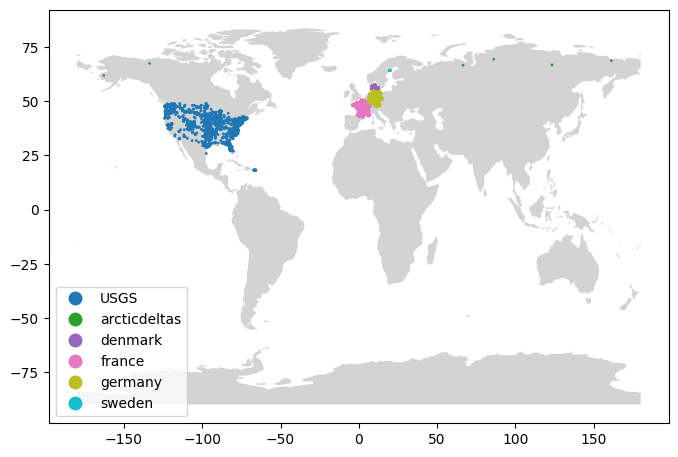

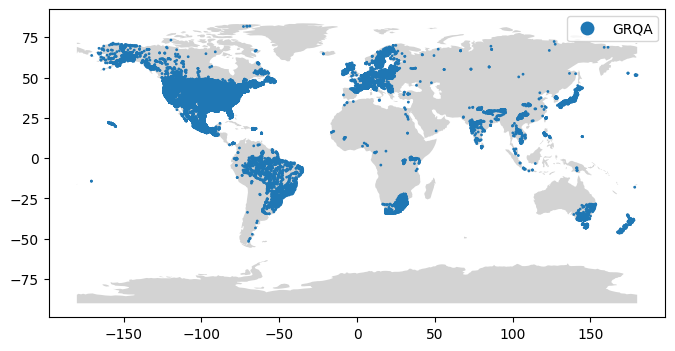

In [27]:

worldmap = gpd.read_file(geodatasets.get_path('naturalearth.land'))
# Creating axes and plotting world map
fig, ax = plt.subplots(1,1,figsize=(8, 6))
worldmap.plot(color="lightgrey", ax=ax)
gdf[gdf['dataset']!='GRQA'].plot(ax=ax,column='dataset',legend=True,markersize=1)

fig, ax = plt.subplots(1,1,figsize=(8, 4))
worldmap.plot(color="lightgrey", ax=ax)
gdf[gdf.dataset=='GRQA'].plot(ax=ax,column='dataset',legend=True,markersize=1)

# fig.savefig('map.png')